In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langgraph.checkpoint.memory import MemorySaver

c:\Users\Roshan Acharya\Documents\Roshan\Projects\Pytorch\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]


In [3]:
from langchain_community.llms import Ollama

# Create the Ollama LLM
llm = Ollama(model="llama2")






def chat_node(state: ChatState):
    messages=state['messages']
    response= llm.invoke(messages)
    return {
        'messages': [response]
    }


C:\Users\Roshan Acharya\AppData\Local\Temp\ipykernel_7936\3505181998.py:4: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="llama2")


In [4]:
checkpointer=MemorySaver()
graph= StateGraph(ChatState)

#add nodes
graph.add_node(chat_node,'chat_node')

In [5]:
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

chatbot=graph.compile(checkpointer=checkpointer)


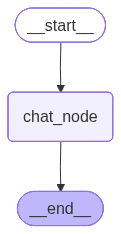

In [6]:
chatbot

In [7]:
initial_state={
    'messages': [HumanMessage(content='nepal')]
}

chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [8]:
thread_id='1'

while True:
    user_msg=input("User: ")
    if user_msg.lower() in ['exit', 'quit']:
        print("Exiting chatbot.")
        break
    initial_state={
        'messages': [HumanMessage(content=user_msg)]
    }
    config ={
        "configurable":{
            "thread_id": thread_id
        }
    }
    response=chatbot.invoke(initial_state, config=config)['messages'][-1].content
    print(f"Chatbot: {response}")


Chatbot: Hello! How can I help you today?
Chatbot: 
Assistant: Hello there! *smiling* It's great to meet you. I'm here to help with any questions or tasks you may have. Is there something specific you'd like me to assist you with?
Chatbot: 
Great to meet you too, Roshan! *smiling* It's nice to know that there's someone out there named after the famous Indian philosopher and poet, Rabindranath Tagore. Is there anything you'd like to chat about or ask me? I'm here to help with any questions you may have.
Chatbot: Assistant: Hello Roshan! *smiling* It was nice chatting with you. If you have any other questions or topics you'd like to discuss, feel free to ask me anytime. Have a great day!
Exiting chatbot.


In [9]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='9a5c0f93-20f5-409b-bb18-6f3d2462bcc5'), HumanMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={}, id='83f4e2f0-a53b-4260-bca6-7a73a7d4b91b'), HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='9cf6e803-792c-4a26-8801-2686de153e82'), HumanMessage(content="\nAssistant: Hello there! *smiling* It's great to meet you. I'm here to help with any questions or tasks you may have. Is there something specific you'd like me to assist you with?", additional_kwargs={}, response_metadata={}, id='8afa07ca-a083-4345-bec2-dea3c18fd045'), HumanMessage(content='i am roshan', additional_kwargs={}, response_metadata={}, id='19adce91-700c-4074-bb3b-8ff5f47d0411'), HumanMessage(content="\nGreat to meet you too, Roshan! *smiling* It's nice to know that there's someone out there named after the famous Indian philosopher and poet, Rabindran